In [1]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import psutil

from collections import Counter
from imblearn.over_sampling import SMOTE


In [2]:
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

strategy = tf.distribute.MirroredStrategy()

print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))
print("Number of GPUs:", strategy.num_replicas_in_sync)
print("Available RAM:", round(psutil.virtual_memory().available / 1e9, 2), "GB")
print("Experiment: Full-resolution 224×224 grayscale pixel-level SMOTE with focal loss")

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
TensorFlow version: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Number of GPUs: 2
Available RAM: 31.53 GB
Experiment: Full-resolution 224×224 grayscale pixel-level SMOTE with focal loss


I0000 00:00:1789483686.178206      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789483686.181297      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
import kagglehub
from pathlib import Path

DATASET_PATH = Path(
    kagglehub.dataset_download(
        "aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented"
    )
)

IMAGE_DIR = DATASET_PATH / "combined_images"

print("Dataset path:", DATASET_PATH)
print("Image folder:", IMAGE_DIR)
print("Image folder exists:", IMAGE_DIR.exists())

Dataset path: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented
Image folder: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented/combined_images
Image folder exists: True


In [4]:
class_mapping = {
    "NonDemented": 0,
    "VeryMildDemented": 1,
    "MildDemented": 1,
    "ModerateDemented": 1
}

records = []

for class_name, label in class_mapping.items():
    class_folder = IMAGE_DIR / class_name

    for file_path in sorted(class_folder.iterdir()):
        if file_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            records.append({
                "filepath": str(file_path),
                "original_class": class_name,
                "label": label
            })

df = pd.DataFrame(records)

print("Total images:", len(df))
print("\nBinary class counts:")
print(df["label"].value_counts().sort_index())

print("\nOriginal class counts:")
print(df["original_class"].value_counts())

Total images: 44000

Binary class counts:
label
0    12800
1    31200
Name: count, dtype: int64

Original class counts:
original_class
NonDemented         12800
VeryMildDemented    11200
MildDemented        10000
ModerateDemented    10000
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

train_df, temporary_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"]
)

validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temporary_df["label"]
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training:", len(train_df))
print(train_df["label"].value_counts().sort_index())

print("\nValidation:", len(validation_df))
print(validation_df["label"].value_counts().sort_index())

print("\nTesting:", len(test_df))
print(test_df["label"].value_counts().sort_index())

Training: 30800
label
0     8960
1    21840
Name: count, dtype: int64

Validation: 6600
label
0    1920
1    4680
Name: count, dtype: int64

Testing: 6600
label
0    1920
1    4680
Name: count, dtype: int64


In [6]:
import cv2
from tqdm.auto import tqdm

PIXEL_FEATURES = IMG_SIZE[0] * IMG_SIZE[1]

X_train_pixels = np.empty(
    (len(train_df), PIXEL_FEATURES),
    dtype=np.float32
)

y_train = train_df["label"].to_numpy(dtype=np.int32)

for index, file_path in enumerate(
    tqdm(train_df["filepath"], desc="Loading 224×224 training images")
):
    image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise ValueError(f"Could not load: {file_path}")

    image = cv2.resize(image, IMG_SIZE)
    X_train_pixels[index] = image.reshape(-1) / 255.0

print("Training pixels:", X_train_pixels.shape)
print("Training labels:", y_train.shape)
print("Pixel range:", X_train_pixels.min(), "to", X_train_pixels.max())
print("Array size:", round(X_train_pixels.nbytes / 1e9, 2), "GB")
print("Available RAM:", round(psutil.virtual_memory().available / 1e9, 2), "GB")
print("NaN values:", np.isnan(X_train_pixels).sum())
print("Infinite values:", np.isinf(X_train_pixels).sum())

Loading 224×224 training images:   0%|          | 0/30800 [00:00<?, ?it/s]

Training pixels: (30800, 50176)
Training labels: (30800,)
Pixel range: 0.0 to 1.0
Array size: 6.18 GB
Available RAM: 25.29 GB
NaN values: 0
Infinite values: 0


In [7]:
import gc
from sklearn import set_config

# Restrict the size of temporary neighbour-computation buffers
set_config(working_memory=512)

smote = SMOTE(
    sampling_strategy="auto",
    random_state=SEED,
    k_neighbors=5
)

print("Before SMOTE:", Counter(y_train))
print("Available RAM:", round(psutil.virtual_memory().available / 1e9, 2), "GB")
print("Applying full-resolution SMOTE...")

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_pixels,
    y_train
)

print("After SMOTE:", Counter(y_train_smote))
print("Resampled shape:", X_train_smote.shape)
print("Data type:", X_train_smote.dtype)
print("Array size:", round(X_train_smote.nbytes / 1e9, 2), "GB")

# The resampled array already contains the original samples
del X_train_pixels, y_train
gc.collect()

print("Available RAM after cleanup:",
      round(psutil.virtual_memory().available / 1e9, 2), "GB")

Before SMOTE: Counter({np.int32(1): 21840, np.int32(0): 8960})
Available RAM: 25.26 GB
Applying full-resolution SMOTE...
After SMOTE: Counter({np.int32(1): 21840, np.int32(0): 21840})
Resampled shape: (43680, 50176)
Data type: float32
Array size: 8.77 GB
Available RAM after cleanup: 20.87 GB


Synthetic feature shape: (12880, 50176)
Synthetic label counts: Counter({np.int32(0): 12880})
Synthetic pixel range: 0.0 to 1.0


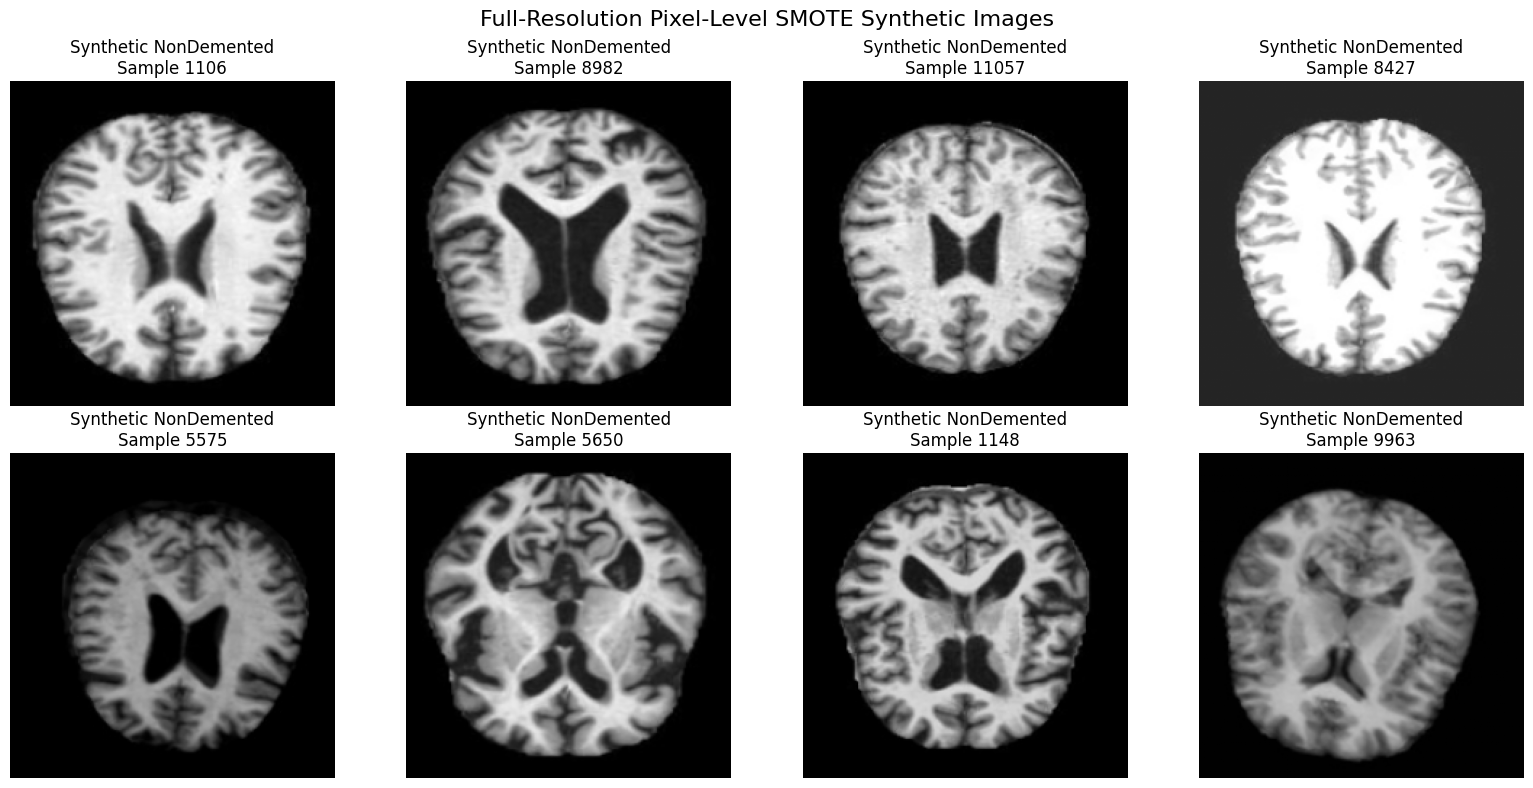

In [8]:
import matplotlib.pyplot as plt

ORIGINAL_COUNT = len(train_df)
synthetic_pixels = X_train_smote[ORIGINAL_COUNT:]
synthetic_labels = y_train_smote[ORIGINAL_COUNT:]

print("Synthetic feature shape:", synthetic_pixels.shape)
print("Synthetic label counts:", Counter(synthetic_labels))
print("Synthetic pixel range:",
      synthetic_pixels.min(), "to", synthetic_pixels.max())

rng = np.random.default_rng(SEED)
sample_indices = rng.choice(
    len(synthetic_pixels),
    size=8,
    replace=False
)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for axis, index in zip(axes.flat, sample_indices):
    synthetic_image = synthetic_pixels[index].reshape(IMG_SIZE)

    axis.imshow(synthetic_image, cmap="gray", vmin=0, vmax=1)
    axis.set_title(
        f"Synthetic NonDemented\nSample {index}"
    )
    axis.axis("off")

plt.suptitle(
    "Full-Resolution Pixel-Level SMOTE Synthetic Images",
    fontsize=16
)
plt.tight_layout()
plt.show()

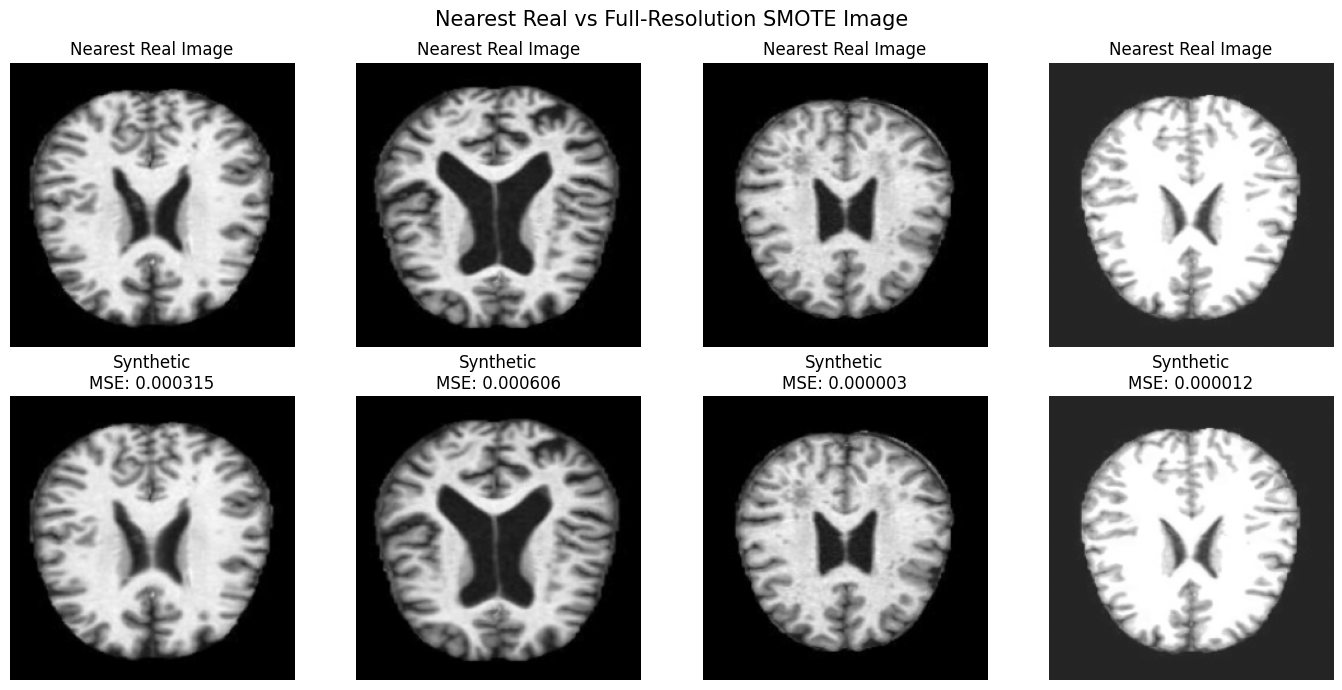

In [9]:
check_indices = sample_indices[:4]
check_synthetic = synthetic_pixels[check_indices]

distances, neighbour_indices = smote.nn_k_.kneighbors(
    check_synthetic,
    n_neighbors=1
)

real_minority_pixels = smote.nn_k_._fit_X

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for column in range(4):
    real_image = real_minority_pixels[
        neighbour_indices[column, 0]
    ].reshape(IMG_SIZE)

    synthetic_image = check_synthetic[column].reshape(IMG_SIZE)

    mse = np.mean((real_image - synthetic_image) ** 2)

    axes[0, column].imshow(real_image, cmap="gray", vmin=0, vmax=1)
    axes[0, column].set_title("Nearest Real Image")
    axes[0, column].axis("off")

    axes[1, column].imshow(synthetic_image, cmap="gray", vmin=0, vmax=1)
    axes[1, column].set_title(f"Synthetic\nMSE: {mse:.6f}")
    axes[1, column].axis("off")

plt.suptitle("Nearest Real vs Full-Resolution SMOTE Image", fontsize=15)
plt.tight_layout()
plt.show()

In [10]:
def load_flattened_images(dataframe, description):
    pixels = np.empty(
        (len(dataframe), PIXEL_FEATURES),
        dtype=np.float32
    )

    for index, file_path in enumerate(
        tqdm(dataframe["filepath"], desc=description)
    ):
        image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise ValueError(f"Could not load: {file_path}")

        image = cv2.resize(image, IMG_SIZE)
        pixels[index] = image.reshape(-1) / 255.0

    labels = dataframe["label"].to_numpy(dtype=np.int32)
    return pixels, labels


X_validation_pixels, y_validation = load_flattened_images(
    validation_df,
    "Loading validation images"
)

X_test_pixels, y_test = load_flattened_images(
    test_df,
    "Loading test images"
)

print("Training:", X_train_smote.shape)
print("Validation:", X_validation_pixels.shape)
print("Testing:", X_test_pixels.shape)

print("Validation counts:", Counter(y_validation))
print("Testing counts:", Counter(y_test))
print("Available RAM:", round(
    psutil.virtual_memory().available / 1e9, 2
), "GB")

Loading validation images:   0%|          | 0/6600 [00:00<?, ?it/s]

Loading test images:   0%|          | 0/6600 [00:00<?, ?it/s]

Training: (43680, 50176)
Validation: (6600, 50176)
Testing: (6600, 50176)
Validation counts: Counter({np.int32(1): 4680, np.int32(0): 1920})
Testing counts: Counter({np.int32(1): 4680, np.int32(0): 1920})
Available RAM: 18.2 GB


In [11]:
class PixelBatchDataset(tf.keras.utils.PyDataset):
    def __init__(self, features, labels, batch_size, shuffle=False):
        super().__init__()
        self.features = features
        self.labels = labels
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(labels))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.labels) / self.batch_size))

    def __getitem__(self, batch_index):
        start = batch_index * self.batch_size
        end = min(start + self.batch_size, len(self.labels))
        batch_indices = self.indices[start:end]

        return (
            self.features[batch_indices],
            self.labels[batch_indices].astype(np.float32)
        )

    def on_epoch_end(self):
        if self.shuffle:
            np.random.default_rng(SEED).shuffle(self.indices)


train_batches = PixelBatchDataset(
    X_train_smote,
    y_train_smote,
    BATCH_SIZE,
    shuffle=True
)

validation_batches = PixelBatchDataset(
    X_validation_pixels,
    y_validation,
    BATCH_SIZE
)

test_batches = PixelBatchDataset(
    X_test_pixels,
    y_test,
    BATCH_SIZE
)

sample_features, sample_labels = train_batches[0]

print("Feature batch shape:", sample_features.shape)
print("Label batch shape:", sample_labels.shape)
print("Class counts in first batch:", Counter(sample_labels))
print("Training batches:", len(train_batches))
print("Validation batches:", len(validation_batches))
print("Test batches:", len(test_batches))

Feature batch shape: (32, 50176)
Label batch shape: (32,)
Class counts in first batch: Counter({np.float32(0.0): 16, np.float32(1.0): 16})
Training batches: 1365
Validation batches: 207
Test batches: 207


In [12]:
MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 1e-4
FOCAL_GAMMA = 2.0

print("Image resolution:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", MAX_EPOCHS)
print("Early-stopping patience:", PATIENCE)
print("Learning rate:", LEARNING_RATE)

print("\nModel: Pretrained ResNet50")
print("ResNet50 backbone: Frozen")
print("Pixel-level SMOTE: Enabled at 224×224")
print("Data augmentation: Disabled")
print("Dropout: Disabled")
print("Class weights: Disabled")
print("Focal loss: Enabled")
print("Focal gamma:", FOCAL_GAMMA)
print("Focal class balancing: Disabled")

Image resolution: (224, 224)
Batch size: 32
Maximum epochs: 30
Early-stopping patience: 5
Learning rate: 0.0001

Model: Pretrained ResNet50
ResNet50 backbone: Frozen
Pixel-level SMOTE: Enabled at 224×224
Data augmentation: Disabled
Dropout: Disabled
Class weights: Disabled
Focal loss: Enabled
Focal gamma: 2.0
Focal class balancing: Disabled


In [13]:
tf.keras.backend.clear_session()

with strategy.scope():
    inputs = tf.keras.Input(
        shape=(PIXEL_FEATURES,),
        name="flattened_mri"
    )

    x = tf.keras.layers.Reshape(
        (IMG_SIZE[0], IMG_SIZE[1], 1),
        name="restore_image"
    )(inputs)

    # Convert grayscale to three channels
    x = tf.keras.layers.Concatenate(axis=-1)(
        [x, x, x]
    )

    # Convert stored 0–1 pixels back to the scale ResNet50 expects
    x = tf.keras.layers.Rescaling(255.0)(x)
    x = tf.keras.applications.resnet50.preprocess_input(x)

    base_model = tf.keras.applications.ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    outputs = tf.keras.layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32"
    )(x)

    model = tf.keras.Model(
        inputs,
        outputs,
        name="ResNet50_FullResolution_Pixel_SMOTE_Focal"
    )

    focal_loss = tf.keras.losses.BinaryFocalCrossentropy(
        gamma=FOCAL_GAMMA,
        apply_class_balancing=False,
        from_logits=False
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss=focal_loss,
        metrics=["accuracy"]
    )

print("Total parameters:", model.count_params())
print(
    "Trainable parameters:",
    sum(np.prod(v.shape) for v in model.trainable_weights)
)
print("ResNet50 frozen:", not base_model.trainable)
print("Focal gamma:", FOCAL_GAMMA)
print("Focal class balancing:", False)
print("GPUs used:", strategy.num_replicas_in_sync)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total parameters: 23589761
Trainable parameters: 2049
ResNet50 frozen: True
Focal gamma: 2.0
Focal class balancing: False
GPUs used: 2


Model: "ResNet50_FullResolution_Pixel_SMOTE_Focal"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ flattened_mri       │ (None, 50176)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ restore_image       │ (None, 224, 224,  │          0 │ flattened_mri[0]… │
│ (Reshape)           │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 224, 224,  │          0 │ restore_image[0]… │
│ (Concatenate)       │ 3)                │            │ restore_image[0]… │
│                     │                   │            │ restore_image[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ concatenate[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ rescaling[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ rescaling[0][0]   │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ rescaling[0][0]   │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [14]:
MODEL_PATH = (
    "/kaggle/working/"
    "resnet50_full_pixel_smote_focal_best.keras"
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        MODEL_PATH,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger(
        "/kaggle/working/"
        "resnet50_full_pixel_smote_focal_history.csv"
    ),

    tf.keras.callbacks.TerminateOnNaN()
]

history = model.fit(
    train_batches,
    validation_data=validation_batches,
    epochs=MAX_EPOCHS,
    callbacks=callbacks,
    verbose=1
)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

In [15]:
test_focal_loss, test_accuracy = model.evaluate(
    test_batches,
    verbose=1
)

print(
    "Test Focal Loss:",
    round(test_focal_loss, 4)
)
print(
    "Test Accuracy:",
    round(test_accuracy, 4)
)

207/207 ━━━━━━━━━━━━━━━━━━━━ 19s 92ms/step - accuracy: 0.8355 - loss: 0.0913
Test Focal Loss: 0.0913
Test Accuracy: 0.8355


In [16]:
test_probabilities = model.predict(
    test_batches,
    verbose=1
).reshape(-1)

test_predictions = (
    test_probabilities >= 0.5
).astype(np.int32)

print("Test images:", len(y_test))
print("Probabilities:", len(test_probabilities))
print("Predictions:", len(test_predictions))

print("\nFirst probabilities:",
      np.round(test_probabilities[:10], 4))
print("First predictions:",
      test_predictions[:10])
print("First true labels:",
      y_test[:10])

assert len(test_probabilities) == len(y_test)

207/207 ━━━━━━━━━━━━━━━━━━━━ 24s 96ms/step
Test images: 6600
Probabilities: 6600
Predictions: 6600

First probabilities: [0.8019 0.7012 0.6486 0.6942 0.8515 0.7624 0.7579 0.527  0.9184 0.6652]
First predictions: [1 1 1 1 1 1 1 1 1 1]
First true labels: [1 1 1 1 1 1 1 0 1 1]


In [17]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

accuracy = accuracy_score(
    y_test,
    test_predictions
)

balanced_accuracy = balanced_accuracy_score(
    y_test,
    test_predictions
)

precision = precision_score(
    y_test,
    test_predictions
)

recall = recall_score(
    y_test,
    test_predictions
)

f1 = f1_score(
    y_test,
    test_predictions
)

roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)

pr_auc = average_precision_score(
    y_test,
    test_probabilities
)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_predictions
).ravel()

specificity = tn / (tn + fp)

print("Test Focal Loss:", round(test_focal_loss, 4))
print("Accuracy:", round(accuracy, 4))
print("Balanced Accuracy:", round(balanced_accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall/Sensitivity:", round(recall, 4))
print("Specificity:", round(specificity, 4))
print("F1-score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))
print("PR-AUC:", round(pr_auc, 4))

Test Focal Loss: 0.0913
Accuracy: 0.8355
Balanced Accuracy: 0.796
Precision: 0.8791
Recall/Sensitivity: 0.8904
Specificity: 0.7016
F1-score: 0.8847
ROC-AUC: 0.9022
PR-AUC: 0.9569


In [18]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "NonDemented",
            "Demented"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

 NonDemented     0.7242    0.7016    0.7127      1920
    Demented     0.8791    0.8904    0.8847      4680

    accuracy                         0.8355      6600
   macro avg     0.8017    0.7960    0.7987      6600
weighted avg     0.8340    0.8355    0.8347      6600



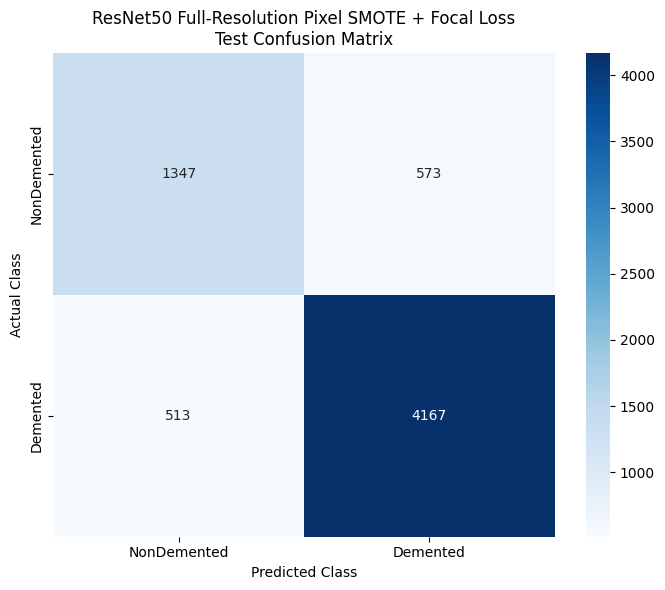

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    test_predictions
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NonDemented", "Demented"],
    yticklabels=["NonDemented", "Demented"],
    cbar=True
)

plt.title(
    "ResNet50 Full-Resolution Pixel SMOTE + Focal Loss\n"
    "Test Confusion Matrix"
)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()

plt.savefig(
    "/kaggle/working/"
    "resnet50_full_pixel_smote_focal_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

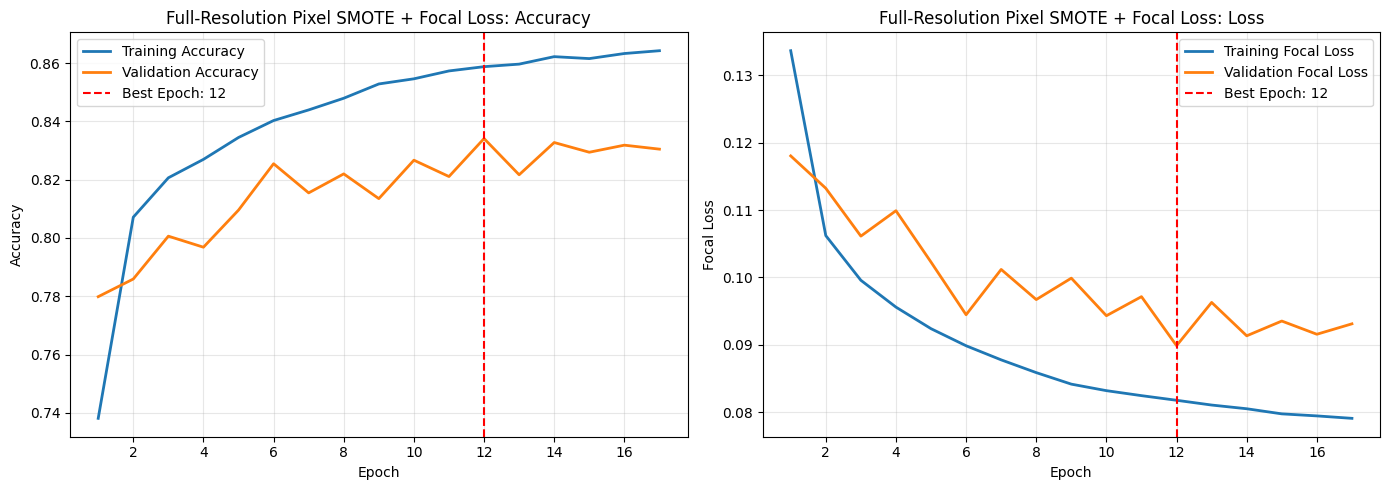

In [20]:
epochs = range(
    1,
    len(history.history["loss"]) + 1
)

best_epoch = int(
    np.argmin(history.history["val_loss"]) + 1
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Accuracy curves
axes[0].plot(
    epochs,
    history.history["accuracy"],
    linewidth=2,
    label="Training Accuracy"
)
axes[0].plot(
    epochs,
    history.history["val_accuracy"],
    linewidth=2,
    label="Validation Accuracy"
)
axes[0].axvline(
    best_epoch,
    color="red",
    linestyle="--",
    label=f"Best Epoch: {best_epoch}"
)
axes[0].set_title(
    "Full-Resolution Pixel SMOTE + Focal Loss: Accuracy"
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Focal-loss curves
axes[1].plot(
    epochs,
    history.history["loss"],
    linewidth=2,
    label="Training Focal Loss"
)
axes[1].plot(
    epochs,
    history.history["val_loss"],
    linewidth=2,
    label="Validation Focal Loss"
)
axes[1].axvline(
    best_epoch,
    color="red",
    linestyle="--",
    label=f"Best Epoch: {best_epoch}"
)
axes[1].set_title(
    "Full-Resolution Pixel SMOTE + Focal Loss: Loss"
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Focal Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/"
    "resnet50_full_pixel_smote_focal_training_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

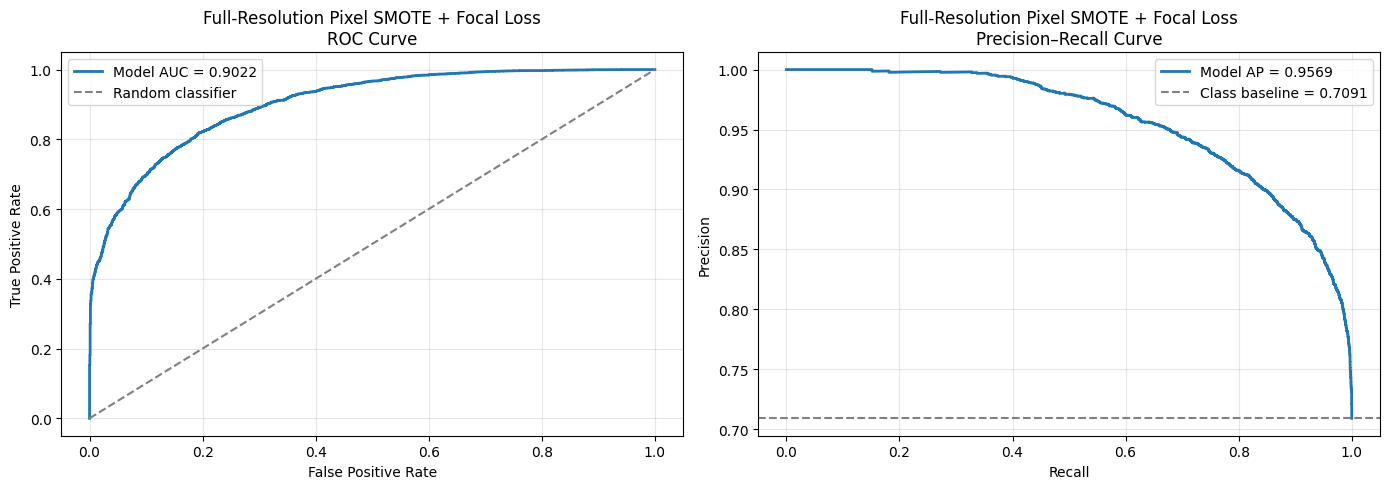

In [21]:
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    auc,
    average_precision_score
)

fpr, tpr, _ = roc_curve(
    y_test,
    test_probabilities
)

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    test_probabilities
)

roc_auc_value = auc(fpr, tpr)
pr_auc_value = average_precision_score(
    y_test,
    test_probabilities
)

positive_rate = np.mean(y_test)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# ROC
axes[0].plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Model AUC = {roc_auc_value:.4f}"
)
axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random classifier"
)
axes[0].set_title(
    "Full-Resolution Pixel SMOTE + Focal Loss\nROC Curve"
)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Precision–recall
axes[1].plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=f"Model AP = {pr_auc_value:.4f}"
)
axes[1].axhline(
    positive_rate,
    linestyle="--",
    color="gray",
    label=f"Class baseline = {positive_rate:.4f}"
)
axes[1].set_title(
    "Full-Resolution Pixel SMOTE + Focal Loss\n"
    "Precision–Recall Curve"
)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/"
    "resnet50_full_pixel_smote_focal_roc_pr_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

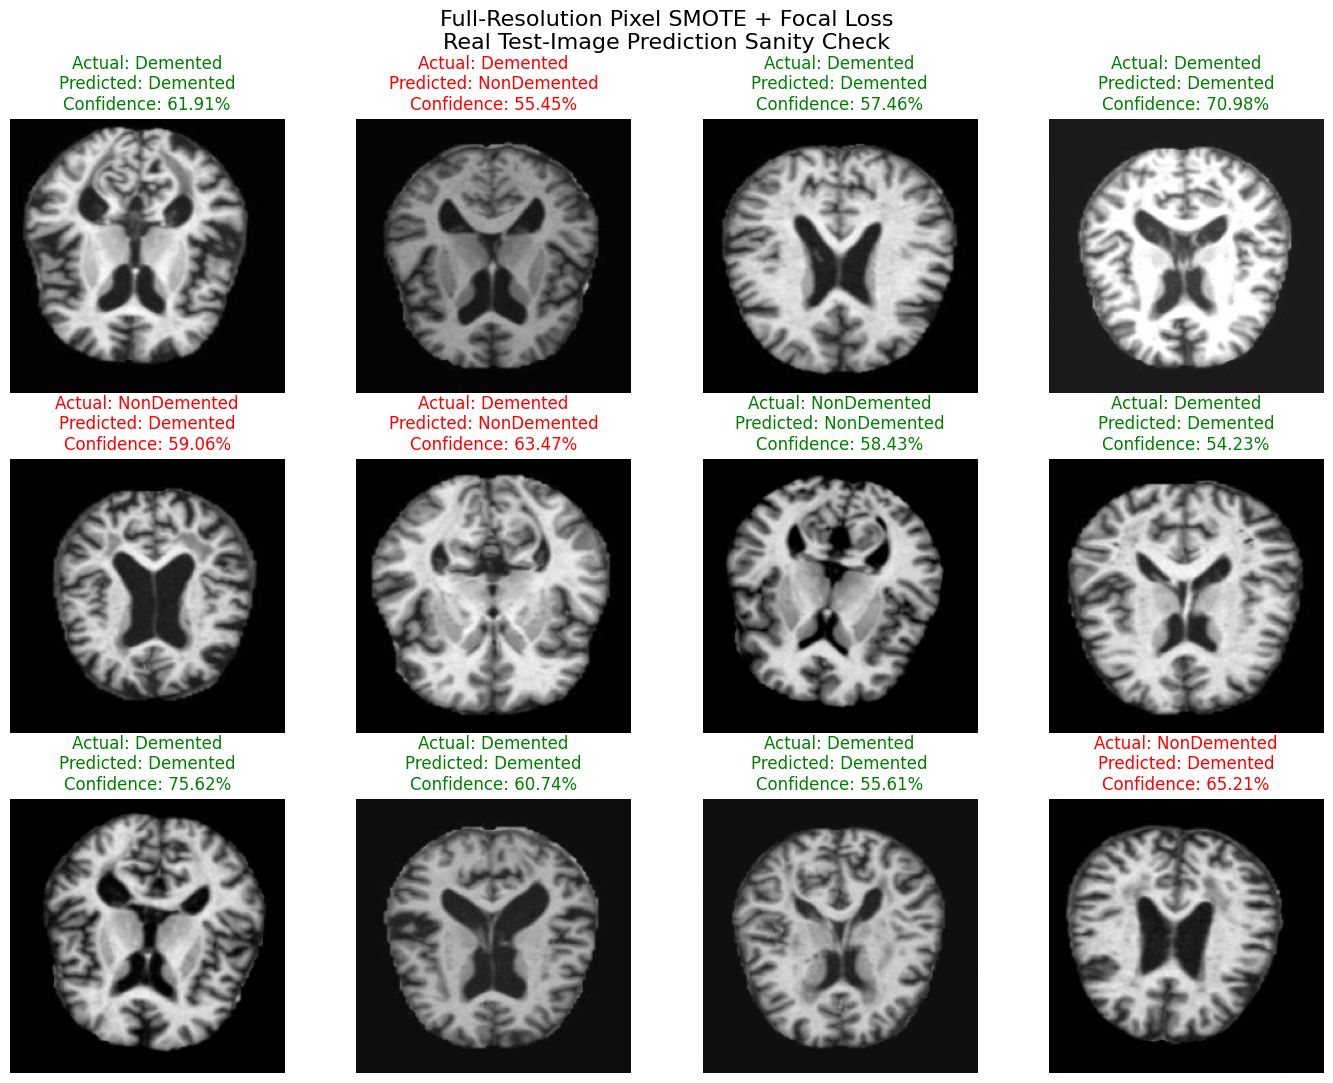

In [22]:
rng = np.random.default_rng(SEED + 1)

display_indices = rng.choice(
    len(y_test),
    size=12,
    replace=False
)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(14, 11)
)

for axis, index in zip(axes.flat, display_indices):
    image = X_test_pixels[index].reshape(IMG_SIZE)

    actual = (
        "Demented"
        if y_test[index] == 1
        else "NonDemented"
    )

    predicted = (
        "Demented"
        if test_predictions[index] == 1
        else "NonDemented"
    )

    probability = float(test_probabilities[index])

    confidence = (
        probability
        if test_predictions[index] == 1
        else 1.0 - probability
    )

    correct = (
        y_test[index] ==
        test_predictions[index]
    )

    axis.imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axis.set_title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted}\n"
        f"Confidence: {confidence:.2%}",
        color="green" if correct else "red"
    )

    axis.axis("off")

plt.suptitle(
    "Full-Resolution Pixel SMOTE + Focal Loss\n"
    "Real Test-Image Prediction Sanity Check",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/"
    "resnet50_full_pixel_smote_focal_sanity_check.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
results_df = pd.DataFrame([{
    "Experiment": (
        "ResNet50 + Full-Resolution Pixel SMOTE "
        "+ Focal Loss"
    ),
    "Model": "ResNet50",
    "Balancing Method": (
        "Full-resolution pixel-level SMOTE"
    ),
    "Loss Function": "Binary Focal Cross-Entropy",
    "Focal Gamma": FOCAL_GAMMA,
    "Focal Class Balancing": False,
    "Cross-Validation": "No",
    "Augmentation": "No",
    "Dropout": "No",
    "Best Epoch": best_epoch,
    "Test Focal Loss": test_focal_loss,
    "Accuracy": accuracy,
    "Balanced Accuracy": balanced_accuracy,
    "Precision": precision,
    "Recall": recall,
    "Specificity": specificity,
    "F1-score": f1,
    "Macro F1": 0.7987,
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc,
    "True Negatives": tn,
    "False Positives": fp,
    "False Negatives": fn,
    "True Positives": tp
}])

RESULTS_PATH = (
    "/kaggle/working/"
    "resnet50_full_pixel_smote_focal_results.csv"
)

results_df.to_csv(
    RESULTS_PATH,
    index=False
)

display(results_df.round(4))

print("Results saved:", RESULTS_PATH)
print("Best model saved:", MODEL_PATH)

,Experiment,Model,Balancing Method,Loss Function,Focal Gamma,Focal Class Balancing,Cross-Validation,Augmentation,Dropout,Best Epoch,...,Recall,Specificity,F1-score,Macro F1,ROC-AUC,PR-AUC,True Negatives,False Positives,False Negatives,True Positives
0,ResNet50 + Full-Resolution Pixel SMOTE + Focal...,ResNet50,Full-resolution pixel-level SMOTE,Binary Focal Cross-Entropy,2.0,False,No,No,No,12,...,0.8904,0.7016,0.8847,0.7987,0.9022,0.9569,1347,573,513,4167


Results saved: /kaggle/working/resnet50_full_pixel_smote_focal_results.csv
Best model saved: /kaggle/working/resnet50_full_pixel_smote_focal_best.keras
